In [1]:
# ── Cell 1: Imports & Load Data ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
import joblib

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/My Drive/IoT Intrusion Detection/data/'

# Neural network needs scaled data
X_train = np.load(DATA_PATH + 'X_train_scaled.npy')
X_test = np.load(DATA_PATH + 'X_test_scaled.npy')
y_train = np.load(DATA_PATH + 'y_train.npy')
y_test = np.load(DATA_PATH + 'y_test.npy')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train attack rate: {y_train.mean()*100:.1f}%")

Mounted at /content/drive
X_train: (2032036, 43)
X_test:  (508010, 43)
y_train attack rate: 12.6%


In [2]:
# ── Cell 2: Train Neural Network (MLP) ───────────────────────────────────────
# Architecture: 43 inputs -> 128 -> 64 -> 32 -> 1 output
# relu activation    -> standard for hidden layers, handles non-linearity well
# adam optimizer     -> adaptive learning rate, works well out of the box
# max_iter=50        -> maximum 50 epochs
# early_stopping     -> stops if validation score stops improving (saves time)
# class_weight via sample_weight not supported in MLP directly,
# so we use balanced class handling via the data itself

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
    )

print("Training Neural Network...this may take some time")
mlp.fit(X_train, y_train)
print("\nTraining complete")
print(f"Stopped at iteration: {mlp.n_iter_}")

Training Neural Network...this may take some time
Iteration 1, loss = 0.02085932
Validation score: 0.990788
Iteration 2, loss = 0.01710159
Validation score: 0.991073
Iteration 3, loss = 0.01649541
Validation score: 0.991413
Iteration 4, loss = 0.01619111
Validation score: 0.991609
Iteration 5, loss = 0.01596416
Validation score: 0.991565
Iteration 6, loss = 0.01590121
Validation score: 0.991777
Iteration 7, loss = 0.01570801
Validation score: 0.990793
Iteration 8, loss = 0.01572211
Validation score: 0.992062
Iteration 9, loss = 0.01556559
Validation score: 0.992028
Iteration 10, loss = 0.01545341
Validation score: 0.992092
Iteration 11, loss = 0.01541161
Validation score: 0.992047
Iteration 12, loss = 0.01528742
Validation score: 0.992225
Iteration 13, loss = 0.01522171
Validation score: 0.992082
Iteration 14, loss = 0.01515874
Validation score: 0.992038
Iteration 15, loss = 0.01516771
Validation score: 0.992308
Iteration 16, loss = 0.01509276
Validation score: 0.992397
Iteration 17, l

In [3]:
# ── Cell 3: Evaluate ──────────────────────────────────────────────────────────
y_pred = mlp.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 45)
print(f"  Accuracy : {accuracy*100:.2f}%")
print(f"  F1 Score : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

  Accuracy : 99.25%
  F1 Score : 0.9699

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00    443753
      Attack       0.98      0.96      0.97     64257

    accuracy                           0.99    508010
   macro avg       0.99      0.98      0.98    508010
weighted avg       0.99      0.99      0.99    508010



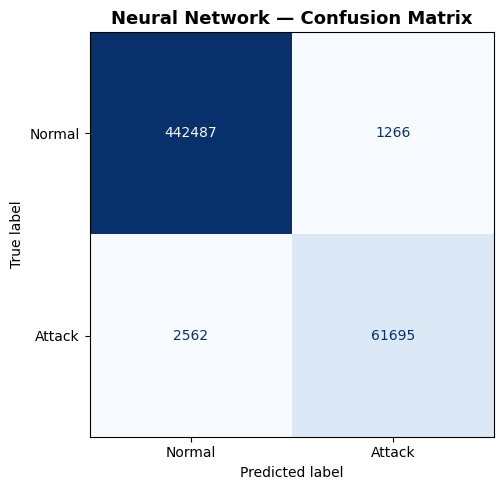

Saved -> nn_confusion_matrix.png


In [9]:
# ── Cell 4: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Neural Network — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'nn_confusion_matrix.png', dpi=300)
plt.show()
print("Saved -> nn_confusion_matrix.png")

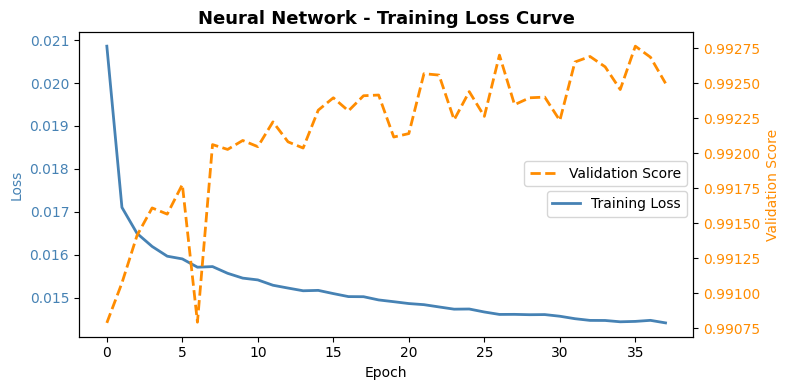

Saved -> nn_loss_curve.png


In [22]:
# ── Cell 5: Training Loss Curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label='Training Loss', color='steelblue', linewidth=2)
if mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, label='Validation Score', color='darkorange', linewidth=2, linestyle='--')
    ax2.set_ylabel('Validation Score', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.legend(loc='center right')

ax.set_title('Neural Network - Training Loss Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.legend(bbox_to_anchor=(1.0, 0.5))
ax2.legend(bbox_to_anchor=(1.0, 0.6))
plt.tight_layout()
plt.savefig(DATA_PATH + 'nn_loss_curve.png', dpi=300)
plt.show()
print("Saved -> nn_loss_curve.png")

In [23]:
# ── Cell 6: Save Model & Results ──────────────────────────────────────────────
joblib.dump(mlp, DATA_PATH + 'neural_network_model.pkl')
print("Model saved -> neural_network_model.pkl")

results = {
    'model':    'Neural Network',
    'accuracy': accuracy,
    'f1_score': f1
}
pd.DataFrame([results]).to_csv(DATA_PATH + 'nn_results.csv', index=False)
print("Results saved -> nn_results.csv")

Model saved -> neural_network_model.pkl
Results saved -> nn_results.csv
